#### __Elagin Matvey Dmitrievich SCT-125 Sarov, DM Task 1, 4 variant__

In [19]:
import pandas as pd
import numpy as np

# Определите (написав соответствующий код) сколько различных значений принимают переменные Product и Customer.

df = pd.read_csv('TRANSACTION.csv')
# df.dropna()
task1 = df[['CUSTOMER', 'PRODUCT']].nunique() # Series
print(task1)

CUSTOMER    1001
PRODUCT       20
dtype: int64


In [5]:
# Найдите частые эпизоды с ограничением на размер правила равным 4, с использованием алгоритма и порога на поддержку согласно вашему варианту.
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

df_pivot = df.pivot(index='CUSTOMER', columns='TIME', values='PRODUCT')

# Чтобы заработал Енкодер нужно подогнать данные под список списков с последовательностью покупок продуктов каждого клиента.
df_fit = df_pivot.values.tolist()

te = TransactionEncoder() # Енкодер, кодирует данные так ,
# чтобы вместо последовательного списка покупок клиента, был список всех продуктов, и True/False в зависимости от наличия в эпизоде.
# te_fit инициализируем, иначе from "te" unpossible take name of columns.
te_fit = te.fit(df_fit).transform(df_fit)
# сохраняем данные в DataFrame
te_df = pd.DataFrame(te_fit, columns=te.columns_)
df_fp = fpgrowth(te_df, min_support=0.03, use_colnames=True, max_len=4)
print(df_fp.sort_values(by=['support'], ascending=False))

      support                        itemsets
7    0.599401                      (heineken)
8    0.487512                       (cracker)
0    0.485514                        (hering)
1    0.472527                        (olives)
2    0.402597                       (bourbon)
..        ...                             ...
614  0.030969       (artichok, steak, hering)
619  0.030969    (ham, steak, olives, hering)
615  0.030969      (chicken, steak, corned_b)
620  0.030969  (ham, steak, corned_b, hering)
621  0.030969  (olives, ham, steak, corned_b)

[661 rows x 2 columns]


In [20]:
# Найдите самый большой (где больше всего элементов) частый эпизод, содержащий продукт согласно вашему варианту. Какая у него поддержка?
def len_itemsets(rows):
    rows['len_itemsets'] = len(rows['itemsets'])
    return rows
# Сначала создадим столбец со значением величины эпизода.
df_len_itemsets = df_fp.apply(len_itemsets, axis = 1) # apply() - обход строк/столбцов с применением any func, axis = 1 (строки)
# Выделим эпизоды содержащие "coke"
df_target = df_len_itemsets[df_len_itemsets['itemsets'].apply(lambda r : 'coke' in r)]
# Среди эпизодов найдем самые большие
df_target = df_target[df_target['len_itemsets'] == df_target['len_itemsets'].max()]
# Среди наибольших эпизодов, найдем часто встречающийся
df_target = df_target[df_target['support'] == df_target['support'].max()]
print(df_target)

      support                              itemsets  len_itemsets
506  0.116883  (heineken, ice_crea, coke, sardines)             4


In [7]:
# На основе найденных частых эпизодов постройте ассоциативные правила с порогом на 
# достоверность согласно вашему варианту. Найдите правило с максимальным лифтом, 
# содержащем продукт из вашего варианта в левой части правила. Дайте ему письменную 
# словесную интерпретацию, укажите и объясните его числовые показатели: поддержку, 
# достоверность и подъем. 

df_ar = df_fp.copy(deep=False)
df_ar = association_rules(df_ar, metric='confidence', min_threshold=0.2) # min_threshold=0.2 - порог для метрики , в нашем случае достоверности

# Выберем правила где 'coke' в левой части(antecedents(условие)), правая часть - consequents(следствие). 
df_ar_ = df_ar[df_ar['antecedents'].apply(lambda r: 'coke' in r )]
# Выберем правило с наибольшим лифтом
df_ar_ = df_ar_[df_ar_['lift'] == df_ar_['lift'].max()]
print(df_ar_)
# В срезе DataFrame, можно увидеть ассоциативное правило такое, что при покупка сардин и колы, 
# покупатель как правило еще покупает мороженное и курицу. Частота такого эпизода по отношению ко всем равна 14,6%.
# Достоверность этого правила оценивается в 79%, значит с достаточно высокой вероятностью покупатель после корзины с сардинами и колой 
#купит мороженное и курицу. Другими словами частота покупки всей последовательности по отношению к покупке только левой части.
# Лифт = 5.6, свидетельствует о зависимости правила, отношение зависимости покупки эпизода к независимой покупке продуктов отдельно,
#результат больше 1, значит зависимость между парой продуктов есть.
# В заключение по данным эпизодам, можно отметить, что при покупке сардин и колы с 70% вероятностью покупатель еще купит мороженное и курицу.
#Данное ассоциативное правило потверждает сильная зависимость покупки этих продуктов вместе.
#Но так как часть закупок такого эпизода по сравнению с другими мала, данное правило может никак не повлиять на дальнейшие использование этого правила.
#Скорее люди целенаправленно идут за покупкой такого набора и найдут в любой точке магазина.

           antecedents          consequents  antecedent support  \
2015  (coke, sardines)  (chicken, ice_crea)            0.146853   

      consequent support   support  confidence      lift  representativity  \
2015             0.13986  0.115884    0.789116  5.642177               1.0   

      leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  
2015  0.095345    4.078728       0.964387  0.678363   0.754826    0.808844  


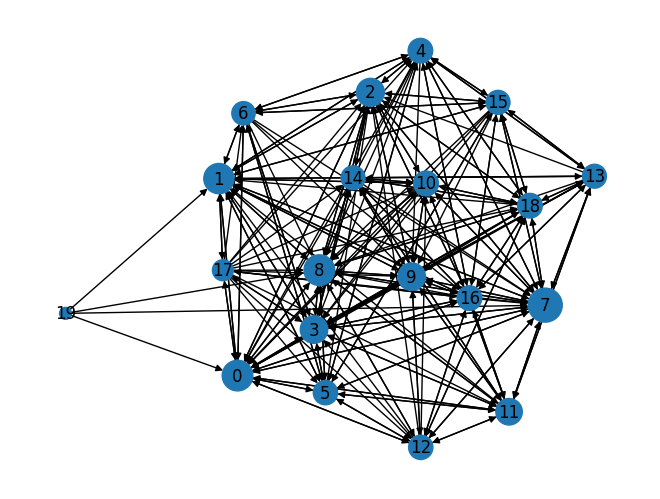

In [18]:
# Используя только двухместные правила постройте ориентированный граф, где вершины 
#элементы правила, их цвет (или размер) – поддержка элемента (item support), дуги – импликации (ориентированы в направлении от условия к следствию), 
#веса дугu – достоверности
import networkx as nx
G = nx.DiGraph() # Создаем объект класса, для построения графа
# df_g_s чтобы получить поддержку самого узла.
df_g_s = df_len_itemsets[df_len_itemsets['len_itemsets'] == 1].copy(deep=False)

# print(df_ar)

# В задаче, построить двухметсные(состоящие из двух продуктов) правила, для этого отсортируем такие наборы из изначального FP-tree с длинной набора 1.
df_g=df_ar[df_ar[['antecedents', 'consequents']].apply(lambda r: len(r['antecedents']) == 1 and len(r['consequents']) == 1 , axis=1)]
# print(df_g)


# далее инициализируем узлы графа, из ассоциативных правил
for i in range(df_g.shape[0]):
    r = df_g.iloc[i]
    G.add_node(r['antecedents'], support=df_g_s[df_g_s['itemsets'] == r['antecedents']]['support'].values,
                id=df_g_s[df_g_s['itemsets'] == r['antecedents']].index[0])
    G.add_node(r['consequents'], support=df_g_s[df_g_s['itemsets'] == r['consequents']]['support'].values,
                id=df_g_s[df_g_s['itemsets'] == r['consequents']].index[0])
    G.add_edge(r['antecedents'], r['consequents'], weight=r['confidence'])
    

node_sizes = [G.nodes[node]['support']*1000 for node in G.nodes()]
labels_ = {}
for node in G.nodes():
    # Используем оригинальный индекс как подпись
    labels_[node] = G.nodes[node]['id']


# Отобразим граф
import matplotlib.pyplot as plt
nx.draw(G, node_size=node_sizes, labels=labels_)

# На графе вместо метки набора , используется Index DF(df_g_s). Ниже закомментирован код для проверки.
# for node, attrs in DG.nodes(data=True):
#     print(f"Узел {node}: {attrs}")
# df_g_s.loc[78]

In [21]:
#Для данного графа рассчитайте меры центральности согласно вашему варианту и найдите 
#элемент с самой высокой мерой, а также какую меру имеет продукт из вашего варианта. 
# Самая высокая авторитетность у стейка
authority, hub = nx.hits(G)
print(max(authority, key=authority.get), authority[max(authority, key=authority.get)] )
# У колы авторитетность
for i in authority:
    if 'coke' in list(i):
        print(f'coke {authority[i]}')
        break
# print(hub)
# Данная метрика авторитетности гласит о том , насколько продукт покупается вместе с другими. 
#Вторая hub, насколько продукт возбуждает покупку других.
# Создаются два вектора, a,h размерность - число узлов в графе. Заполняются значениями 1. Затем итерационный метод для обновления a на след итрерации,
# a_1 = A*h_0 - обновляем вектор авторитетности
# нормируем a через евклидово расстояние 
# h_1 = Aa_1 - обновляем значение хаба
# нормируем h через евклидово расстояние
# Сходимость итераций определяем через eps , невязку выбираем сами , ||a_1−a||<ε и ||h_1−h||<ε - критерий остановки

frozenset({'steak'}) 0.05730061551806252
coke 0.04960456478353372


In [10]:
def fill_rows(rows):
    arr_product = df_fit[rows.name]
    for str in rows.index:
        count = arr_product.count(str)
        rows[str] = count
    return rows
    
# Постройте числовую матрицу со счетчиком числа покупок в ячейках, клиентами по строкам и продуктами по столбцам.
df_matrix = pd.DataFrame(columns=df['PRODUCT'].unique(), index=df['CUSTOMER'].unique())

df_matrix.apply(fill_rows, axis=1)

,hering,corned_b,olives,ham,turkey,bourbon,ice_crea,baguette,soda,cracker,heineken,avocado,artichok,sardines,coke,peppers,apples,steak,chicken,bordeaux
0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0
2,0,0,0,1,1,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0
3,0,0,1,1,1,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0
4,1,1,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,0,0,0,1,0,1,0,0,0,1,1,1,1,0,0,0,0,0,1,0
997,1,1,1,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
998,1,0,0,0,0,0,0,1,1,1,1,0,0,2,0,0,0,0,0,0
999,0,1,0,0,0,0,1,0,0,0,1,0,0,1,1,1,0,0,1,0


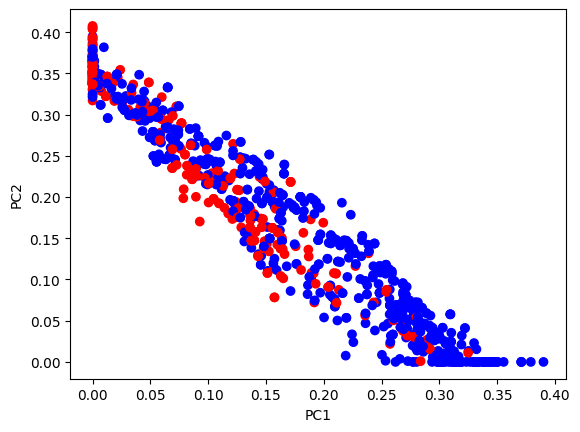

In [14]:
# С помощью метода из вашего варианта постройте линейную проекцию набора данных на 
#плоскость (2 компоненты) цветом укажите транзакции, содержащие продукт  вашего варианта. (NMF) 
from sklearn.decomposition import NMF

X = df_matrix.values # Исходные данные (N x M)
model = NMF(n_components=2, init='nndsvd',random_state=777)
W = model.fit_transform(X) # Матрица (N x n_components) проекция клиентов,
#отображает вес компоненты в каждой транкзации(например, вес покупки группы товаров: ham, turkey, bourbon)
H = model.components_ # Матрица (N_components x M), отображает вес каждого признака в конректной компоненте(например, 
#группа товаров имеет вес в компоненте, за счет этого можно дать определение компоненте, что она описывает) другими словами, раскрытие обобщения признаков
# print(W)
# print(H)
# print(W@H)
id_coke = df_matrix[df_matrix['coke'] > 0].index.values
# print(df_matrix)
fig, ax = plt.subplots()
# Red цвет для транзакций с coke, другие blue
colors = []
for index in df_matrix.index:
    if index in id_coke:
        colors.append('red')
    else: 
        colors.append('blue')
        
ax.scatter(W[:, 0], W[:, 1], color=colors)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.show()
# det_count_components()

In [15]:
# Теперь попробуем оценить наилучшее число компонент, методом логтя
# оценивать будем по квадратичной норме Фробениуса(расширение евклидовой нормы на матрицы)
def det_count_components():
    r = []
    X = df_matrix.values # Исходные данные (N x M)
    for n_k in range(1, len(df_matrix.columns)):
        model = NMF(n_components=n_k, init='nndsvd',random_state=777, max_iter=2000)
        W = model.fit_transform(X)
        H = model.components_
        absolute_err = np.linalg.norm(X - W@H, 'fro')
        err = absolute_err / np.linalg.norm(X, 'fro') # относительная ошибка
        r.append(err)
    
    fig, ax = plt.subplots()
    ax.plot(range(1, n_k+1), r)
    plt.show()

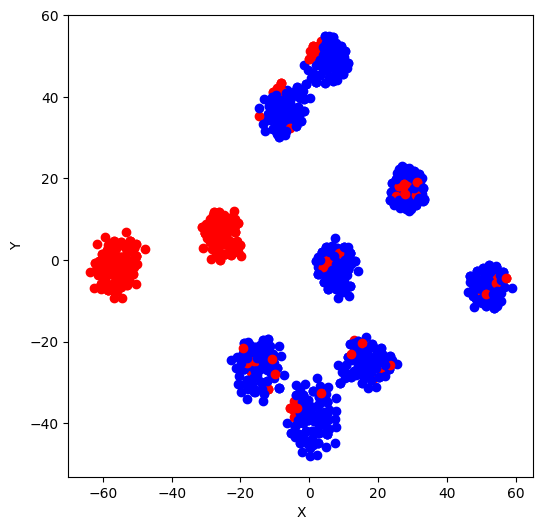

In [22]:
#С помощью метода из вашего варианта постройте нелинейную проекцию набора данных на 
#плоскость цветом укажите транзакции, содержащие продукт из вашего варианта. Не 
#указанные в задании параметры (например, размер решетки для SOM или число слоев в 
#автоэнкодере можно выбирать на свое усмотрение для получение наиболее удобной 
#визуализации). Дайте письменный комментарий, чем с вашей точки зрения для вашего 
#примера лучше или хуже нелинейная проекция). 
from sklearn.manifold import TSNE

X_embedded = TSNE(n_components=2, learning_rate='auto', init='random', random_state = 777 ).fit_transform(X)

# Проекция
plt.figure(figsize=(6, 6))

for i_point, (x,y) in enumerate(X_embedded):
    if i_point in id_coke:
        plt.scatter(x, y, c='red')
    else:
        plt.scatter(x, y, c='blue')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()
# На примере с товаров coke, нелинейная проекция оказалась лучше, так как с помощью этой проекции помимо участия целевого продукта во многих эпизодах,
# можно увидеть что эпизоды содержащие колу, имееют отличительные черты от других кластеров, таким образом имеяя два кластера с coke, можно сказать что 
# кола не сильно влияет на разбитие по кластерам, хотя комбинация колы с другими товарами(-ом) отделяет облако точек,
#с помощью нелинейной проекции получилось увидеть больше информации.

In [24]:
# Из исходной матрицы (из пункта 7) согласно вашему варианту отберите указанное число 
#независимых переменных с использованием метода VarClus/ Glasso/пошагового на ваш 
#выбор.
# Glasso
from sklearn.covariance import empirical_covariance, graphical_lasso
# Ковариационная матрица
emp_cov = empirical_covariance(X)
print(emp_cov)
covariance, precision_matrix = graphical_lasso(emp_cov, alpha=0.05)
# print(precision_matrix)
df_matrix_dependent = pd.DataFrame(precision_matrix, index=df_matrix.columns, columns=df_matrix.columns)
print(df_matrix_dependent)
# Первые n шесть
n_count = 6
for idx,s in df_matrix_dependent.iterrows(): 
    s_t = s[s == 0].index
    if len(s_t.values) >= n_count :
        diff = len(s_t.values)-n_count
        print(f'{idx} независим с {s_t[:n_count].values}')
        break
    else:
        diff = n_count-len(s_t.values)
        n_count = diff
        print(f'{idx} независим с {s_t.values}')
# Алгоритм Glasso делает условные зависимости реальными , если при ковариационной матрицы X->Y->Z,(X зависит от Y, а y зависит от Z), покажет что 
# между собой все зависимы , а в glasso мы увидим правильную зависимость (X зависит от Y, а y зависит от Z), alpha - показывает насколько мы будем 
# обнулять зависимости при их маловлиятельности.
# то есть матрица точности показывает прямую связь между переменными , а ковариация показывает связь с учетом других переменных

[[ 0.25384007  0.05384126  0.02691714  0.01132234  0.01255887 -0.08776738
  -0.07994902  0.05783727  0.02046305 -0.03584527 -0.00148104 -0.00691017
   0.00637724 -0.07020851 -0.07420452 -0.06365263  0.00348004  0.03742212
  -0.059969   -0.00407185]
 [ 0.05384126  0.24024926  0.05154286  0.04073549  0.02197802 -0.00633632
  -0.05547599 -0.06244804 -0.05386921 -0.02186625 -0.10664161 -0.05966062
  -0.04274746 -0.04964965 -0.05364566  0.02132134  0.02605087  0.04214666
   0.01944908 -0.00497405]
 [ 0.02691714  0.05154286  0.25539495  0.01300099  0.08491508  0.05203188
   0.00677644 -0.08432127  0.0152924  -0.04596103 -0.07918655 -0.08743005
  -0.06881929 -0.06663965  0.00628742 -0.05602789  0.00829939  0.03626443
  -0.06914764  0.00081038]
 [ 0.01132234  0.04073549  0.01300099  0.21662853  0.04623947 -0.04731033
  -0.02450397 -0.06415962 -0.04179337 -0.00027944 -0.00762175  0.02541814
   0.0325858  -0.03735725 -0.02736724 -0.03988818 -0.04379137 -0.01567064
  -0.03449398 -0.00169361]
 [ 0